# 3 · Validation

The calibration in notebook 1 fits the model to SERL; this notebook asks whether the
fitted model reproduces real demand, in three views that isolate different failure modes.
The first two test the model against SERL itself, the calibration target, to confirm the
fit lands where it was aimed: a per-cohort split of the demand terms, and the seasonal
shape. The third tests it against DESNZ subnational statistics, which are held out and
never a calibration target, so it is a genuinely out-of-sample check.

The split matters because a model can hit a headline total while getting the parts wrong.
Reporting per dwelling and per cohort, rather than city totals scaled by meter coverage,
is what exposes that; an earlier headline looked accurate only because a per-dwelling
over-prediction and a coverage shortfall cancelled. The numbers below are per dwelling and
per cohort throughout.

Heavy steps read a committed 30-LSOA sample by default; `RUN_LIVE` re-runs the model with
the v7 config, calling the same `run_monthly_retune.py` the command line runs. The config
is the seam: this notebook reads `results/calibration_v7_cohort/calibrated_config.yaml`,
the file notebook 1 writes.

In [ ]:
import sys, os
from pathlib import Path
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "household_energy").exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
SCRIPTS = REPO / "research" / "applied" / "scripts"
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(SCRIPTS))
DATA = REPO / "data"; RES = REPO / "results_lsoa"

# Read the dated run notebook 1 stamped (latest by default), and deposit into it.
import run_paths
RUN_DATE = None
RUN = run_paths.run_dir(RUN_DATE, create=True)
CONFIG = run_paths.config_for(RUN_DATE)   # the run's frozen config, else the latest working copy

RUN_LIVE     = False   # re-run the model with the v7 config vs read the cached 30-LSOA sample (§3.1-3.3)
RUN_TRANSFER = False   # re-run the 5-city transfer with the run's config (§3.4, ~30 min) vs read committed CSVs
TAG = "v7"; SAMPLE_N = 30
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
DAYS = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}

# SERL cohort targets (the calibration target), annualised from the 2023 monthly panel.
_d = pd.read_csv(DATA / "serl_8963_targets" / "daily_targets.csv")
def _mon(hf, qty):
    s = _d[(_d.period_type == "monthly") & (_d.year == 2023) & (_d.weekday_weekend == "both") &
           (_d.heating_fuel == hf) & (_d.has_pv.isin(["No", "All"])) & (_d.seg3_var == "none") &
           (_d.quantity == qty)]
    return pd.to_numeric(s["mean"], errors="coerce").groupby(s["month"]).mean().reindex(range(1, 13))
serl_gg = _mon("Gas", "Gas"); serl_ge = _mon("Gas", "Electricity imports"); serl_ee = _mon("Electric", "Electricity imports")
_floor = serl_ee[[6, 7, 8]].mean()
SERL = {"gas_heated_elec": float(sum(serl_ge[m] * DAYS[m] for m in range(1, 13))),
        "elec_heated_baseline": float(_floor * 365),
        "elec_heated_heating": float(sum((serl_ee - _floor).clip(lower=0)[m] * DAYS[m] for m in range(1, 13)))}
SERL["elec_heated_total"] = SERL["elec_heated_baseline"] + SERL["elec_heated_heating"]

DEC = RES / f"decomp_sample_newcastle_2023_{TAG}.csv"
MON = RES / f"monthly_cohort_newcastle_2023_{TAG}.csv"
if RUN_LIVE or not DEC.exists():
    from run_monthly_retune import run_monthly_retune
    run_monthly_retune(TAG, SAMPLE_N, str(CONFIG), write=True)   # same code path as the CLI
dec = pd.read_csv(DEC); mon = pd.read_csv(MON)
print(f"validation sample: {len(dec)} dwellings | electric-heated {(dec.heating_bucket == 'electric').mean():.1%}")
print("run:", RUN.relative_to(REPO), "| config:", CONFIG.relative_to(REPO), "exists:", CONFIG.exists())

## 3.1 · Per-cohort split vs SERL

The first test splits electricity into its demand terms by heating cohort: for
electric-heated homes, the non-heating part ($B + S$) and the heating part ($H$), and for
gas-heated homes the whole electricity total, which is all non-heating. A correct
calibration reproduces both the split and the total, not just the total.

The model lands on each cohort target almost exactly: electric-heated non-heating and
heating, and gas-heated electricity, each within a per cent or two of SERL. This is what
the per-cohort anchors and slopes in notebook 1 were fitted to deliver, and the split
confirms the fit is hitting the parts rather than averaging to the right total by luck.

         cohort         component  model   SERL  ratio
electric-heated non-heating (B+S) 2624.0 2624.0  1.000
electric-heated       heating (H) 2083.0 2085.0  0.999
electric-heated             TOTAL 4707.0 4709.0  0.999
     gas-heated electricity (B+S) 2901.0 2903.0  0.999


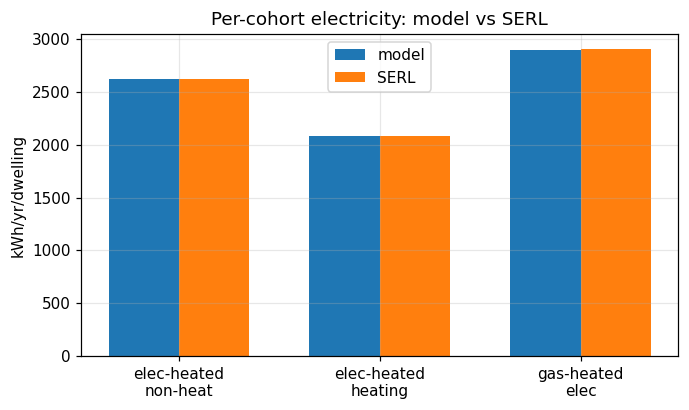

In [2]:
e = dec[dec.heating_bucket == "electric"]; g = dec[dec.heating_bucket == "gas"]
rows = [["electric-heated", "non-heating (B+S)", e.base_kwh.mean() + e.spike_kwh.mean(), SERL["elec_heated_baseline"]],
        ["electric-heated", "heating (H)",      e.heat_kwh.mean(),                       SERL["elec_heated_heating"]],
        ["electric-heated", "TOTAL",            e.electric_kwh.mean(),                   SERL["elec_heated_total"]],
        ["gas-heated",      "electricity (B+S)", g.electric_kwh.mean(),                  SERL["gas_heated_elec"]]]
t = pd.DataFrame(rows, columns=["cohort", "component", "model", "SERL"])
t["ratio"] = (t.model / t.SERL).round(3)
t.model = t.model.round(0); t.SERL = t.SERL.round(0)
print(t.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.8)); x = np.arange(3); w = 0.35
mod = [e.base_kwh.mean() + e.spike_kwh.mean(), e.heat_kwh.mean(), g.electric_kwh.mean()]
ser = [SERL["elec_heated_baseline"], SERL["elec_heated_heating"], SERL["gas_heated_elec"]]
ax.bar(x - w/2, mod, w, label="model"); ax.bar(x + w/2, ser, w, label="SERL")
ax.set_xticks(x); ax.set_xticklabels(["elec-heated\nnon-heat", "elec-heated\nheating", "gas-heated\nelec"])
ax.set(ylabel="kWh/yr/dwelling", title="Per-cohort electricity: model vs SERL"); ax.legend()
plt.show()

## 3.2 · Seasonal shape vs SERL

The annual split can be right while the within-year distribution is wrong, so the second
test compares the monthly profile of each fuel and cohort against SERL. The seasonal
heating profile fitted in notebook 1 is what should make these line up: gas-heated gas
follows the winter peak, and electric-heated electricity follows its own milder seasonal
curve. The shape tracks SERL in all three series. On the annual level printed below, the two
electricity series sit on the panel (ratio 1.00), while gas-heated gas runs a little high
against the SERL panel (about 1.09); the held-out DESNZ comparison in 3.3 puts that same gas
demand at 0.94 against the city's own meters, the panel-versus-population gap rather than a
shape error.

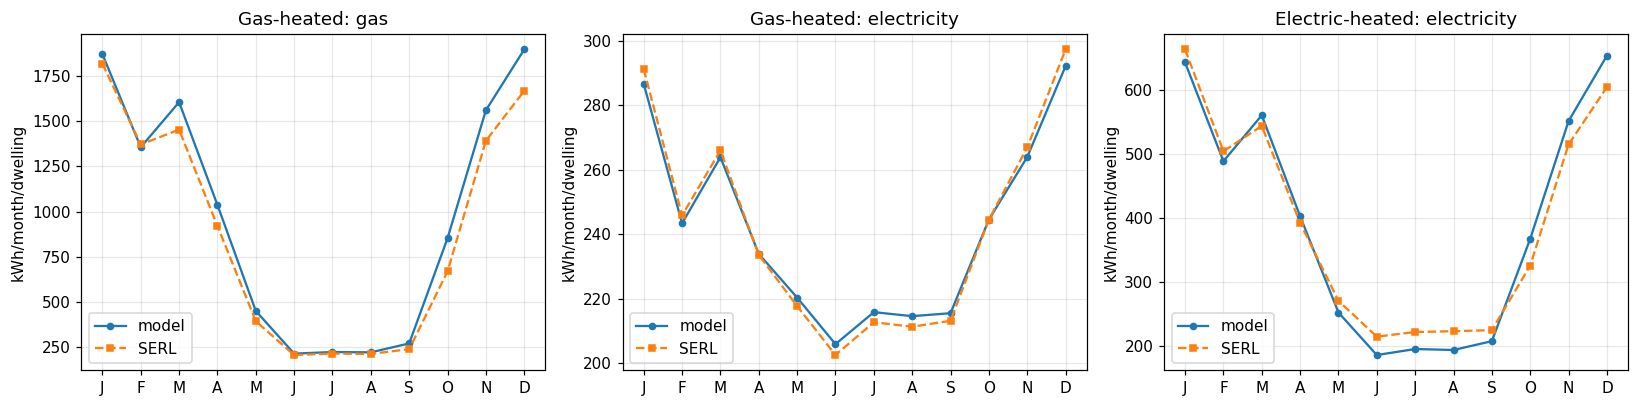

Gas-heated: gas                annual model  11562  SERL  10563  ratio 1.09
Gas-heated: electricity        annual model   2901  SERL   2903  ratio 1.00
Electric-heated: electricity   annual model   4707  SERL   4709  ratio 1.00


In [3]:
ref = pd.DataFrame({"gas_gas": serl_gg * pd.Series(DAYS), "gas_elec": serl_ge * pd.Series(DAYS),
                    "electric_elec": serl_ee * pd.Series(DAYS)})
pe = mon.pivot(index="month", columns="cohort", values="elec_kwh_per_dw")
pg = mon.pivot(index="month", columns="cohort", values="gas_kwh_per_dw")
M = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
series = [("Gas-heated: gas", pg["gas"], ref["gas_gas"]),
          ("Gas-heated: electricity", pe["gas"], ref["gas_elec"]),
          ("Electric-heated: electricity", pe["electric"], ref["electric_elec"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (n, mo, se) in zip(axes, series):
    ax.plot(range(1, 13), [mo[m] for m in range(1, 13)], "-o", ms=4, label="model")
    ax.plot(range(1, 13), [se[m] for m in range(1, 13)], "--s", ms=4, label="SERL")
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(M); ax.set_title(n)
    ax.set_ylabel("kWh/month/dwelling"); ax.legend()
plt.tight_layout()
plt.show()
for n, mo, se in series:
    print(f"{n:30s} annual model {mo.sum():6.0f}  SERL {se.sum():6.0f}  ratio {mo.sum()/se.sum():.2f}")

## 3.3 · Per unit vs DESNZ, held out

The third test is the genuine out-of-sample one. DESNZ subnational statistics are an
independent source the calibration never sees, reported per meter, and the model is
compared to them per dwelling. Gas comes in close, near 0.94 of the DESNZ figure. Electricity
sits a little above one, near 1.12.

That electricity residual is left honest rather than tuned away. SERL is a national panel
and Newcastle is a specific population, so a gap between the panel the model is calibrated
to and the city it is applied to is expected; closing it by tuning to DESNZ would collapse
the independence that makes this a real check. The value is the SERL-panel-versus-population
difference, reported, not corrected.

In [4]:
from utils import load_desnz
from run_decomp_sample import pick_sample
sample = pick_sample()[:SAMPLE_N]
des = load_desnz("newcastle", 2023)
des["lsoa_code"] = des["lsoa_code"].astype(str)
des = des[des.lsoa_code.isin(sample)]
elec_pm = des.total_kwh_elec.sum() / des.meters_elec.sum()
gas_pm = des.total_kwh_gas.sum() / des.meters_gas.sum()
m_e = dec.electric_kwh.mean(); m_g = dec[dec.gas_kwh > 0].gas_kwh.mean()
print(f"electricity: model {m_e:.0f}/dwelling vs DESNZ {elec_pm:.0f}/meter  ratio {m_e/elec_pm:.3f}")
print(f"gas        : model {m_g:.0f}/gas-dwelling vs DESNZ {gas_pm:.0f}/meter  ratio {m_g/gas_pm:.3f}")
print("\nDESNZ is held out; the electricity ratio is the SERL-panel-vs-population residual, not tuned.")

# Freeze the validation summary into the dated run snapshot.
_e = dec[dec.heating_bucket == "electric"]; _g = dec[dec.heating_bucket == "gas"]
_enh = _e.base_kwh.mean() + _e.spike_kwh.mean()
vsum = pd.DataFrame([
    {"check": "elec-heated non-heating vs SERL", "model": round(_enh), "ref": round(SERL["elec_heated_baseline"]), "ratio": round(_enh / SERL["elec_heated_baseline"], 3)},
    {"check": "elec-heated heating vs SERL", "model": round(_e.heat_kwh.mean()), "ref": round(SERL["elec_heated_heating"]), "ratio": round(_e.heat_kwh.mean() / SERL["elec_heated_heating"], 3)},
    {"check": "gas-heated elec vs SERL", "model": round(_g.electric_kwh.mean()), "ref": round(SERL["gas_heated_elec"]), "ratio": round(_g.electric_kwh.mean() / SERL["gas_heated_elec"], 3)},
    {"check": "electricity per-unit vs DESNZ (held out)", "model": round(m_e), "ref": round(elec_pm), "ratio": round(m_e / elec_pm, 3)},
    {"check": "gas per-unit vs DESNZ (held out)", "model": round(m_g), "ref": round(gas_pm), "ratio": round(m_g / gas_pm, 3)},
])
vsum.to_csv(RUN / "validation_summary.csv", index=False)
print("deposited ->", (RUN / "validation_summary.csv").relative_to(REPO))

Sample: 30 LSOAs, 16825 dwellings, electric-heated share=0.1204 (city=0.1151)


electricity: model 3110/dwelling vs DESNZ 2775/meter  ratio 1.120
gas        : model 11562/gas-dwelling vs DESNZ 12258/meter  ratio 0.943

DESNZ is held out; the electricity ratio is the SERL-panel-vs-population residual, not tuned.
deposited -> results/runs/2026-06-24/validation_summary.csv


## 3.4 · Spatial and temporal transfer

The same configuration, fitted once on the national panel, should carry to other cities and
years without refitting. The confidence table summarises the transfer to four further
cities and two further Newcastle years, reading the committed `transfer_confidence_*.csv`.

The table is regenerable from this notebook, so §3.4 is reachable end to end like the rest
of the pipeline. `RUN_TRANSFER` re-runs the seven city-years under the run's config, calling
the same `run_city` and `write_confidence` the command line runs (about thirty minutes,
each city written as it finishes). With it off the table reads whatever confidence CSVs are
on disk, and the summary is frozen into the dated run snapshot either way.

In [ ]:
import glob

# The cities and years the confidence table covers. RUN_TRANSFER regenerates them under the
# run's config, calling the same run_city/write_confidence transfer.py runs; off by default.
TRANSFER_CITIES = [("newcastle", 2021), ("newcastle", 2022), ("newcastle", 2023),
                   ("brighton", 2023), ("manchester", 2023), ("sunderland", 2023),
                   ("waltham_forest", 2023)]
if RUN_TRANSFER:
    from transfer import run_city, write_confidence
    for city, year in TRANSFER_CITIES:
        abm = run_city(city, year, Path(CONFIG), None, 5)   # same config seam as notebooks 1-3
        write_confidence(city, abm, year)

rows = []
for f in sorted(glob.glob(str(REPO / "research" / "applied" / "transfer_confidence_*.csv"))):
    t = pd.read_csv(f)
    rows.append({"city_year": Path(f).stem.replace("transfer_confidence_", ""), "n_lsoa": len(t),
                 "median totals ratio": round(t.tot_ratio.median(), 3) if "tot_ratio" in t else None,
                 "High-tier %": round((t.confidence == "High").mean() * 100) if "confidence" in t else None})
tdf = pd.DataFrame(rows)
print(tdf.to_string(index=False))

# Freeze the transfer table into the dated run snapshot.
tdf.to_csv(RUN / "transfer_confidence_summary.csv", index=False)
print("\ndeposited ->", (RUN / "transfer_confidence_summary.csv").relative_to(REPO))